In [33]:
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


plt.style.use('ggplot')
# Визначаємо логістичну модель
def logistic_model(t, r, K, y0):
    return K / (1 + ((K - y0) / y0) * np.exp(-r * t))

### Детермінована модель

In [11]:
def analyze_with_constraints(folder_path):
    results = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder_path, filename))
            
            # Стандартизація назв колонок
            df.columns = [c.lower() for c in df.columns]
            col_f = [c for c in df.columns if 'follow' in c][0]
            col_d = [c for c in df.columns if 'date' in c][0]
            
            df[col_d] = pd.to_datetime(df[col_d])
            df = df.sort_values(col_d)
            df['t'] = (df[col_d] - df[col_d].min()).dt.days
            
            t_data = df['t'].values
            n_data = df[col_f].values
            
            # --- СТРАТЕГІЯ ОБМЕЖЕННЯ ---
            current_max = n_data.max()
            # Обмежуємо K: мінімум - поточний максимум, 
            # максимум - наприклад, 10-кратний поточний максимум (щоб не було нескінченності)
            lower_bounds = [0.0001, current_max, 1]
            upper_bounds = [2.0, current_max * 10, current_max]
            
            try:
                popt, _ = curve_fit(
                    logistic_model, t_data, n_data,
                    p0=[0.05, current_max * 1.2, n_data[0]],
                    bounds=(lower_bounds, upper_bounds)
                )
                
                r, K, N0 = popt
                
                # Рахуємо "коефіцієнт насичення"
                saturation = (current_max / K) * 100
                
                results.append({
                    'game': filename,
                    'r_speed': round(r, 4),
                    'K_limit': int(K),
                    'Current_y': int(current_max),
                    'Saturation_%': round(saturation, 2)
                })
            except:
                continue
                
    return pd.DataFrame(results)

summary = analyze_with_constraints('datasets')
display(summary)

,game,r_speed,K_limit,Current_y,Saturation_%
0,steamdb_chart_105600.csv,0.0008,1137234,935180,82.23
1,steamdb_chart_108600.csv,0.0013,748250,580620,77.60
2,steamdb_chart_1169040.csv,0.0029,107493,107493,100.00
3,steamdb_chart_1284190.csv,0.0032,174375,174375,100.00
4,steamdb_chart_1621690.csv,0.0031,168571,168571,100.00
5,steamdb_chart_1623730.csv,0.0126,618061,618061,100.00
6,steamdb_chart_233860.csv,0.0004,647389,295758,45.68
7,steamdb_chart_427410.csv,0.0073,127206,127206,100.00
8,steamdb_chart_526870.csv,0.0019,405776,405776,100.00
9,steamdb_chart_892970.csv,0.0068,513347,513347,100.00


In [12]:
summary.r_speed.mean()

np.float64(0.00403)

In [13]:
summary.K_limit.mean()

np.float64(464770.2)

In [14]:
folder_path = "datasets"

N_files = 0
t_length = 0

for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            df = pd.read_csv(str(folder_path + "/" + filename))
            N_files += 1
            t_length += df.size

In [15]:
t_length/N_files

4234.0

In [16]:
t = np.linspace(0, 365*10, 365*10)
r = summary.r_speed.mean()
K = summary.K_limit.mean()

log_model = logistic_model(t, r, K, 10)

Text(0, 0.5, "Кількість 'Followers'")

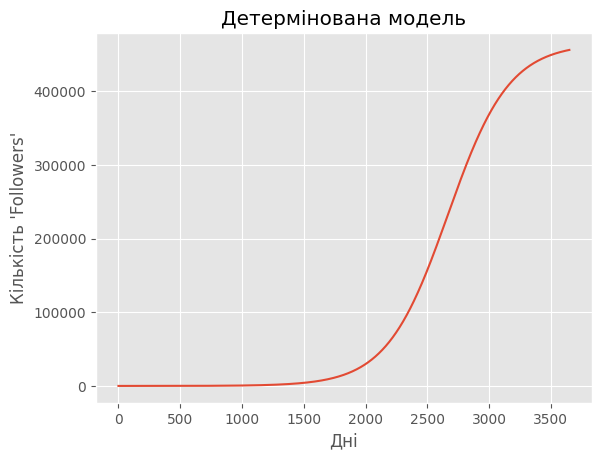

In [35]:
plt.plot(t, log_model)
plt.title("Детермінована модель")
plt.xlabel("Дні")
plt.ylabel("Кількість 'Followers'")

### Стохастична модель

In [30]:
df = pd.read_csv("steamdb_chart_1579420.csv")

In [57]:
def estimate_sigma_multiplicative(y_data, r, K):
    """
    y_data: масив Followers
    r, K: параметри, які ви вже знайшли через curve_fit або summary
    """
    sigmas = []
    
    for i in range(1, len(y_data)):
        y_prev = y_data[i-1]
        y_curr = y_data[i]
        
        # Очікуваний детермінований приріст за 1 день
        expected_growth = r * y_prev * (1 - y_prev / K)
        
        # Реальний приріст
        actual_growth = y_curr - y_prev
        
        # Виділяємо стохастичну складову: (Реал - План) / y_prev
        # Це відповідає члену (sigma * dW) у вашій формулі
        noise_term = (actual_growth - expected_growth) / y_prev
        sigmas.append(noise_term)
    
    # Справжня сигма - це стандартне відхилення цих "шоків"
    return np.std(sigmas)

In [58]:
y_data = df.Followers.to_numpy()
sigma = estimate_sigma_multiplicative(y_data, r, K)

Text(0, 0.5, "Кількість 'Followers'")

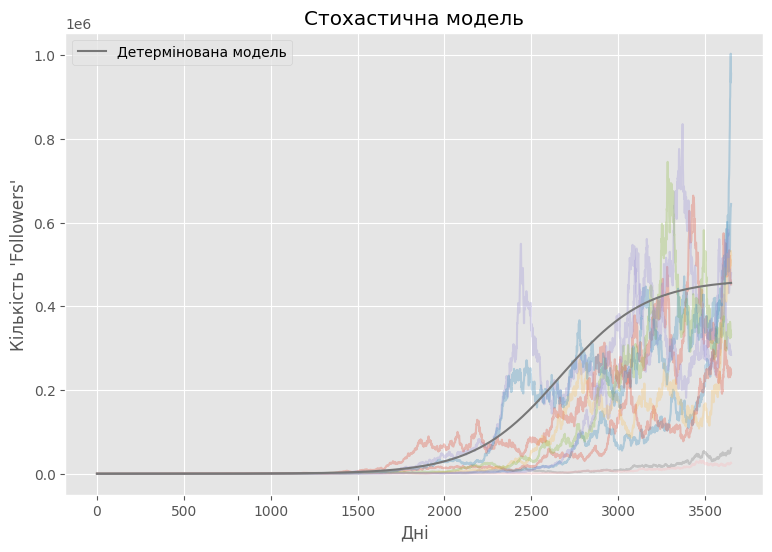

In [92]:
y_stochs = np.zeros((t.size, 10))
y_stochs[0] = 10
for j in range(10):
    for i in range(1, t.size):
        dW = np.random.normal(0, np.sqrt(1)) # dt = 1 день
        y_stochs[i, j] = y_stochs[i-1, j] + r * y_stochs[i-1, j] * (1 - y_stochs[i-1, j] / K) * 1 + sigma * y_stochs[i-1, j] * dW

plt.figure(figsize=(9, 6))
plt.plot(t, y_stochs, alpha=.3)
plt.plot(t, log_model, label="Детермінована модель")
plt.title("Стохастична модель")
plt.legend()
plt.xlabel("Дні")
plt.ylabel("Кількість 'Followers'")

### ШІ модель

Модель працює на: cuda
Епоха 20, Loss: 0.030708
Епоха 40, Loss: 0.020325
Епоха 60, Loss: 0.012183
Епоха 80, Loss: 0.002356
Епоха 100, Loss: 0.002206


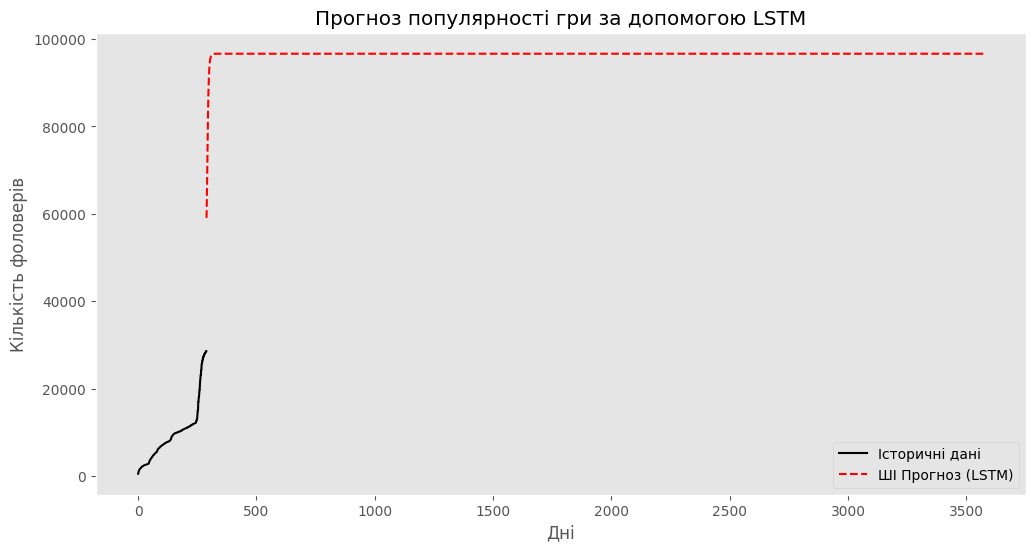

In [118]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Налаштування пристрою (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Модель працює на: {device}")

# 2. Підготовка даних
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Завантажте ваш файл (наприклад, 'steamdb_chart_1623730.csv')
df = pd.read_csv("steamdb_chart_1579420.csv")
y_data = df.Followers.to_numpy().reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(y_data)

SEQ_LENGTH = 200 # модель дивиться на 30 попередніх днів
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Розподіл на навчання
train_size = int(len(X) * 0.8)
X_train = torch.FloatTensor(X[:train_size]).to(device)
y_train = torch.FloatTensor(y[:train_size]).to(device)

# 3. Архітектура LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Цикл навчання
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f'Епоха {epoch+1}, Loss: {loss.item():.6f}')

# 5. Прогноз на майбутнє (n днів)
model.eval()
n_forecast = 365*9 # Прогноз на 30, 60 або 90 днів
last_seq = scaled_data[-SEQ_LENGTH:]
forecast_results = []

current_seq = torch.FloatTensor(last_seq).view(1, SEQ_LENGTH, 1).to(device)

for _ in range(n_forecast):
    with torch.no_grad():
        pred = model(current_seq)
        forecast_results.append(pred.item())
        # Оновлюємо вікно прогнозу (додаємо нове значення, прибираємо найстаріше)
        new_element = pred.view(1, 1, 1)
        current_seq = torch.cat((current_seq[:, 1:, :], new_element), dim=1)

# Повертаємо дані до реального масштабу
forecast_unscaled = scaler.inverse_transform(np.array(forecast_results).reshape(-1, 1))

# 6. Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_data)), y_data, label='Історичні дані', color='black')
plt.plot(np.arange(len(y_data), len(y_data) + n_forecast), forecast_unscaled, 
         label='ШІ Прогноз (LSTM)', color='red', linestyle='--')
plt.title("Прогноз популярності гри за допомогою LSTM")
plt.xlabel("Дні")
plt.ylabel("Кількість фоловерів")
plt.legend()
plt.grid()
plt.show()

### Гібридний метод

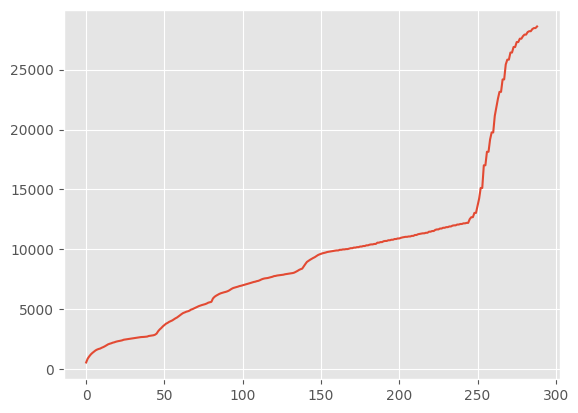

In [102]:
df = pd.read_csv("steamdb_chart_1579420.csv")
y_data = df.Followers.to_numpy()
plt.plot(y_data)

Навчання на історії (нормалізовано)... Max val: 28595
Epoch 100, Loss: 0.00008917
Epoch 200, Loss: 0.00005536
Epoch 300, Loss: 0.00005182
Epoch 400, Loss: 0.00005118
Epoch 500, Loss: 0.00005099


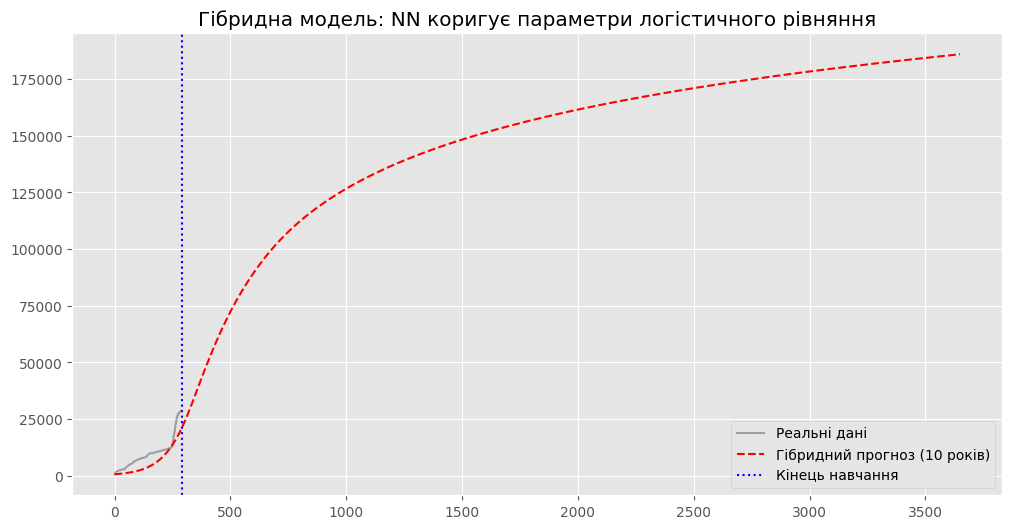

In [116]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class InternalParameterNN(nn.Module):
    def __init__(self):
        super(InternalParameterNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 2) 
        )

    def forward(self, y_tensor):
        output = self.network(y_tensor)
        # Обмежуємо r невеликим діапазоном, а K робимо сумірним з входом
        r = torch.sigmoid(output[:, 0:1]) * 0.5  # r від 0 до 0.5
        K_factor = torch.sigmoid(output[:, 1:2]) + 1.0 # K від 1.0x до 2.0x від поточного y
        return r, K_factor

class SelfLearningHybridModel:
    def __init__(self):
        self.nn = InternalParameterNN().to(device)

    def train_on_history(self, y_history, epochs=500):
        # ВАЖЛИВО: Нормалізуємо дані, щоб Loss не став nan
        self.max_val = np.max(y_history)
        y_norm = y_history / self.max_val
        
        optimizer = torch.optim.Adam(self.nn.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        
        # Виправляємо проблему з writable array
        y_train = torch.FloatTensor(y_norm.copy()).view(-1, 1).to(device)
        
        print(f"Навчання на історії (нормалізовано)... Max val: {self.max_val}")
        self.nn.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            
            # Поточні значення та цільові (наступний день)
            y_curr = y_train[:-1]
            y_next_actual = y_train[1:]
            
            # Прогноз параметрів r та K_factor
            r, K_f = self.nn(y_curr)
            K = y_curr * K_f # Динамічне K, що залежить від стану
            
            # Дискретне логістичне рівняння
            # y_next = y + r * y * (1 - y/K)
            y_next_pred = y_curr + r * y_curr * (1 - y_curr / K)
            
            # Тепер розмірності y_next_pred та y_next_actual однакові (Size([N, 1]))
            loss = criterion(y_next_pred, y_next_actual)
            
            if torch.isnan(loss):
                print("Критична помилка: Loss став NaN. Зупинка.")
                break
                
            loss.backward()
            optimizer.step()
            
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}, Loss: {loss.item():.8f}")

    def forecast(self, y_start, days):
        self.nn.eval()
        predictions = [y_start]
        curr_y_val = y_start / self.max_val
        curr_y_tensor = torch.FloatTensor([[curr_y_val]]).to(device)
        
        for _ in range(days):
            with torch.no_grad():
                r, K_f = self.nn(curr_y_tensor)
                K = curr_y_tensor * K_f
                
                dy = r * curr_y_tensor * (1 - curr_y_tensor / K)
                curr_y_tensor = curr_y_tensor + dy
                
                # Обмеження росту, щоб не було нескінченності
                val = curr_y_tensor.item()
                predictions.append(val * self.max_val)
                
        return np.array(predictions)

# --- Запуск ---
# Припустимо n_data — ваш масив Followers
y_year1 = y_data

model = SelfLearningHybridModel()
model.train_on_history(y_year1, epochs=500)

# Прогноз на 10 років (3650 днів)
y_forecast = model.forecast(y_start=y_year1[0], days=3650)

plt.figure(figsize=(12, 6))
plt.plot(y_data, label="Реальні дані", color='black', alpha=0.3)
plt.plot(y_forecast, label="Гібридний прогноз (10 років)", color='red', linestyle='--')
plt.axvline(x=y_data.size, color='blue', linestyle=':', label="Кінець навчання")
plt.legend()
plt.title("Гібридна модель: NN коригує параметри логістичного рівняння")
plt.show()

In [114]:
y_forecast

array([567.,  nan,  nan, ...,  nan,  nan,  nan], shape=(3651,))